# Tree Models and Random Forests: Wine Classification

## Introduction
This notebook compares a single decision tree with a random forest on the wine dataset. The central learning objective is to understand the tradeoff between interpretability and ensemble stability.

## Project Goal
Train, evaluate, and compare a decision tree and a random forest; inspect overfitting behavior; and test whether a selected feature subset preserves ensemble performance.

## Machine Learning Concepts Used
- Decision Trees
- Random Forests
- Bias-Variance Tradeoff
- Feature Importance
- Train/Test Gap
- Model Simplification

## Dataset
`sklearn.datasets.load_wine`

## Step 1: Import libraries

**What this section is doing**  
Import the classification models, plotting tools, and evaluation utilities needed for tree-based modeling.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## Step 2: Load the dataset

**What this section is doing**  
Load the wine dataset and inspect the feature table before modeling.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [2]:
data = load_wine(as_frame=True)
X = data.data.copy()
y = data.target.copy()

print("Dataset shape:", X.shape)
display(X.head())

Dataset shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## Step 3: Create train and test sets

**What this section is doing**  
Use a stratified split to preserve class balance in both training and test data.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

Training shape: (142, 13)
Testing shape : (36, 13)


## Step 4: Train a decision tree

**What this section is doing**  
Fit a single interpretable tree. Trees are intuitive but can overfit if allowed to grow too deeply.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [4]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_train_preds = tree_model.predict(X_train)
tree_test_preds = tree_model.predict(X_test)

print("Decision Tree Train Accuracy:", accuracy_score(y_train, tree_train_preds))
print("Decision Tree Test Accuracy :", accuracy_score(y_test, tree_test_preds))
print(classification_report(y_test, tree_test_preds))

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



## Step 5: Visualize the tree

**What this section is doing**  
Plotting the tree makes the learned structure human-readable and helps show why single-tree models are easy to explain.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

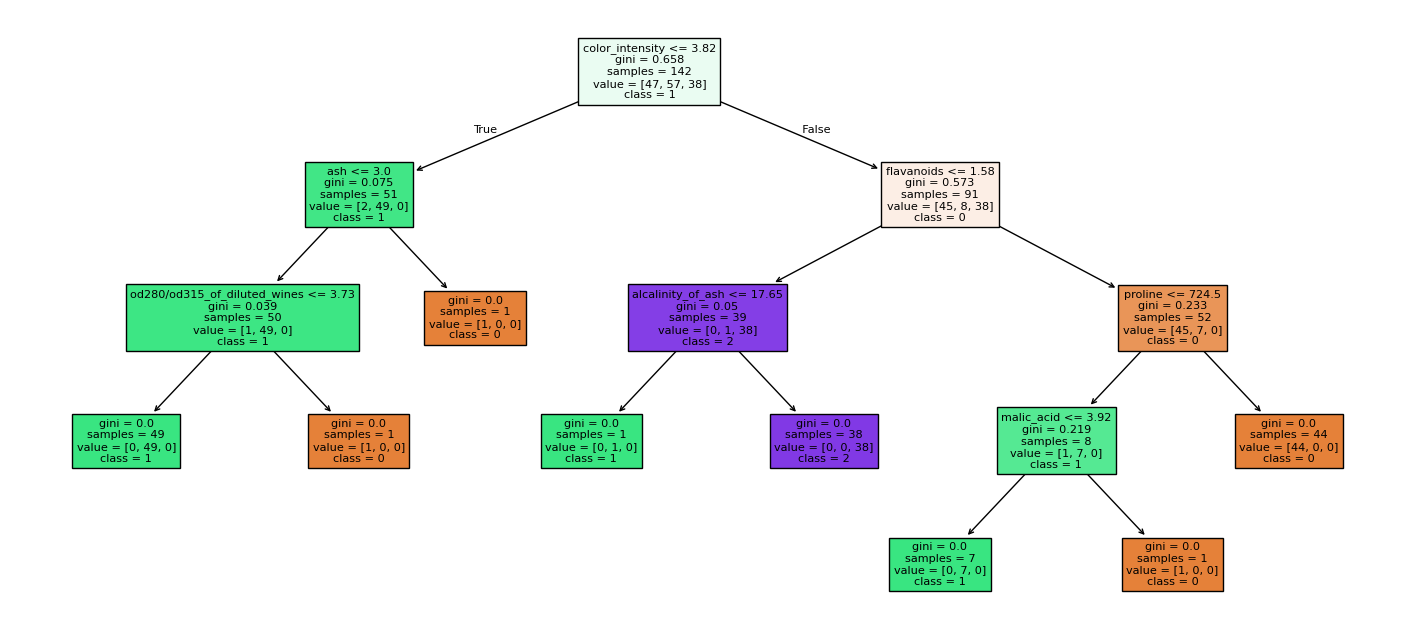

In [5]:
plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True
)
plt.show()

## Step 6: Train a random forest

**What this section is doing**  
Fit an ensemble of trees. Random forests typically reduce variance by averaging many trees trained on bootstrapped samples.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [6]:
forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
forest_model.fit(X_train, y_train)

forest_train_preds = forest_model.predict(X_train)
forest_test_preds = forest_model.predict(X_test)

print("Random Forest Train Accuracy:", accuracy_score(y_train, forest_train_preds))
print("Random Forest Test Accuracy :", accuracy_score(y_test, forest_test_preds))
print(classification_report(y_test, forest_test_preds))

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Step 7: Inspect feature importance

**What this section is doing**  
Feature importance provides a rough ranking of variables that contribute most strongly to the forest's decisions.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [7]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": forest_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

,feature,importance
9,color_intensity,0.187186
6,flavanoids,0.168435
12,proline,0.157161
0,alcohol,0.107861
10,hue,0.094739
11,od280/od315_of_diluted_wines,0.090224
5,total_phenols,0.051406
4,magnesium,0.035406
1,malic_acid,0.030168
8,proanthocyanins,0.028087


## Step 8: Refine the forest using selected features

**What this section is doing**  
Keep only the strongest features according to the forest and retrain to test whether a smaller input space preserves performance.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [8]:
selected_features = importance_df.head(6)["feature"].tolist()
print("Selected features:", selected_features)

X_small = X[selected_features]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_small, y, test_size=0.2, random_state=42, stratify=y
)

forest_small = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
forest_small.fit(Xs_train, ys_train)
ys_pred = forest_small.predict(Xs_test)

comparison_df = pd.DataFrame({
    "metric": ["accuracy"],
    "full_feature_forest": [accuracy_score(y_test, forest_test_preds)],
    "selected_feature_forest": [accuracy_score(ys_test, ys_pred)]
})

display(comparison_df)

Selected features: ['color_intensity', 'flavanoids', 'proline', 'alcohol', 'hue', 'od280/od315_of_diluted_wines']


,metric,full_feature_forest,selected_feature_forest
0,accuracy,1.0,1.0


## Step 9: Final analysis and next steps

**What this section is doing**  
Summarize the tree vs forest tradeoff, the effect of feature selection, and what stronger future experiments would include.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

## Final Analysis

### Did the single tree show signs of overfitting compared with the forest?
Yes, the single decision tree showed some signs of overfitting. It achieved a perfect 1.0 accuracy on the training data but dropped to approximately 0.94 on the test data. This gap between training and testing accuracy suggests that the tree learned the training data too well, including some noise or specific patterns not present in unseen data. In contrast, the random forest achieved 1.0 accuracy on both the training and test sets, indicating better generalization and less overfitting in this specific scenario.

### Did the forest preserve strong performance with fewer features?
Yes, the random forest preserved strong performance even with a reduced set of features. The accuracy remained 1.0 when trained with the selected top 6 features, matching the performance of the forest trained on all 13 features. This suggests that the most important features are sufficient for accurate classification in this dataset, and removing less important features did not negatively impact performance.

### When would interpretability matter more than the extra performance of an ensemble?
Interpretability would matter more than the extra performance of an ensemble in several situations:

*   **Regulatory Compliance:** In fields like finance, healthcare, or law, regulatory bodies often require transparent and explainable models to ensure fairness, accountability, and compliance.
*   **High-Stakes Decisions:** When model predictions have significant consequences (e.g., medical diagnoses, loan approvals), understanding the rationale behind a decision is critical for trust and debugging.
*   **Debugging and Trust:** For model developers and stakeholders, a simple, interpretable model (like a shallow decision tree) can be easier to debug, understand its failure modes, and build confidence in its application.
*   **Domain Expertise Integration:** When incorporating domain knowledge, a more interpretable model allows experts to validate the decision rules and potentially suggest improvements.
*   **Feature Engineering Insights:** A clear decision tree structure can reveal important relationships between features and the target variable, which can guide further feature engineering or scientific discovery.
*   **Resource Constraints:** Simpler models generally require less computational power and memory, which can be a factor in resource-constrained environments.